In [ ]:
import os, glob, re, pathlib
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np, random, time
from PIL import Image
import os, imageio
from tqdm import tqdm
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
tf.config.optimizer.set_jit(True)

In [9]:
from google.colab import files
upload = files.upload()

Saving kaggle.json to kaggle.json


In [10]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d zuozhaorui/celeba -p /content
!unzip -q /content/celeba.zip -d /content/celeba
DATA_ROOT = "/content/celeba"

Dataset URL: https://www.kaggle.com/datasets/zuozhaorui/celeba
License(s): unknown
 97% 2.56G/2.64G [00:32<00:03, 22.0MB/s]
100% 2.64G/2.64G [00:32<00:00, 88.4MB/s]


In [11]:
seed = 34
random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

In [12]:
IMG_SIZE = 64
MAX_FILES = 60000
BATCH_SIZE = 256
STEPS_PER_EPOCH = 300
EPOCHS = 30
SAVE_EVERY = 1
SMALL_MODEL = True

SAMPLES_DIR = "/content/dcgan_samples"
GIF_PATH = "/content/dcgan_progress.gif"

os.makedirs(SAMPLES_DIR, exist_ok=True)
print("Speed config:",
      dict(MAX_FILES=MAX_FILES, BATCH_SIZE=BATCH_SIZE,
           STEPS_PER_EPOCH=STEPS_PER_EPOCH, EPOCHS=EPOCHS,
           SMALL_MODEL=SMALL_MODEL))

Speed config: {'MAX_FILES': 60000, 'BATCH_SIZE': 256, 'STEPS_PER_EPOCH': 300, 'EPOCHS': 30, 'SMALL_MODEL': True}


In [13]:
all_jpgs = sorted(glob.glob(os.path.join(DATA_ROOT, "**", "*.jpg"), recursive=True))[:MAX_FILES]
print("Total JPGs selected:", len(all_jpgs))

Total JPGs selected: 60000


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_path(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear", antialias=False)
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0
    return img

paths_ds = tf.data.Dataset.from_tensor_slices(all_jpgs)

opts = tf.data.Options()
if hasattr(opts, "deterministic"):
    opts.deterministic = False
else:
    opts.experimental_deterministic = False

opts.experimental_optimization.apply_default_optimizations = True

dataset = (paths_ds
           .shuffle(min(20000, len(all_jpgs)))
           .map(preprocess_path, num_parallel_calls=AUTOTUNE, deterministic=False)
           .cache("/content/celeba.cache")
           .batch(BATCH_SIZE, drop_remainder=True)
           .repeat()
           .prefetch(AUTOTUNE)
          ).with_options(opts)


In [20]:
NOISE_DIM = 128

def build_generator(small=False):
    c4 = 512  if small else 1024
    c3 = 256  if small else 512
    c2 = 128  if small else 256
    c1 = 64   if small else 128
    m = tf.keras.Sequential(name="generator")
    m.add(layers.Input((NOISE_DIM,)))
    m.add(layers.Dense(4*4*c4, use_bias=False))
    m.add(layers.Reshape((4,4,c4)))
    m.add(layers.BatchNormalization()); m.add(layers.ReLU())

    m.add(layers.Conv2DTranspose(c3, 4, 2, 'same', use_bias=False))
    m.add(layers.BatchNormalization()); m.add(layers.ReLU())
    m.add(layers.Conv2DTranspose(c2, 4, 2, 'same', use_bias=False))
    m.add(layers.BatchNormalization()); m.add(layers.ReLU())
    m.add(layers.Conv2DTranspose(c1, 4, 2, 'same', use_bias=False))
    m.add(layers.BatchNormalization()); m.add(layers.ReLU())
    m.add(layers.Conv2DTranspose(3,   4, 2, 'same', use_bias=False, activation='tanh'))
    return m

def build_discriminator(small=False):
    c1 = 32   if small else 64
    c2 = 64   if small else 128
    c3 = 128  if small else 256
    c4 = 256  if small else 512
    m = tf.keras.Sequential(name="discriminator")
    m.add(layers.Input((IMG_SIZE, IMG_SIZE, 3)))
    m.add(layers.Conv2D(c1, 4, 2, 'same')); m.add(layers.LeakyReLU(0.2)); m.add(layers.Dropout(0.3))
    m.add(layers.Conv2D(c2, 4, 2, 'same')); m.add(layers.LeakyReLU(0.2)); m.add(layers.Dropout(0.3))
    m.add(layers.Conv2D(c3, 4, 2, 'same')); m.add(layers.LeakyReLU(0.2)); m.add(layers.Dropout(0.3))
    m.add(layers.Conv2D(c4, 4, 2, 'same')); m.add(layers.LeakyReLU(0.2)); m.add(layers.Dropout(0.3))
    m.add(layers.Flatten()); m.add(layers.Dense(1))
    return m

generator = build_generator(SMALL_MODEL)
discriminator = build_discriminator(SMALL_MODEL)
generator.summary(); discriminator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         3,072 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,808,000 (14.53 MB)

 Trainable params: 3,806,080 (14.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 694,241 (2.65 MB)

 Trainable params: 694,241 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
REAL_SMOOTH = 0.9

def d_loss_fn(real_logits, fake_logits):
    real_labels = tf.ones_like(real_logits, dtype=real_logits.dtype) * tf.cast(REAL_SMOOTH, real_logits.dtype)
    fake_labels = tf.zeros_like(fake_logits, dtype=fake_logits.dtype)
    return bce(real_labels, real_logits) + bce(fake_labels, fake_logits)

def g_loss_fn(fake_logits):
    labels = tf.ones_like(fake_logits, dtype=fake_logits.dtype)
    return bce(labels, fake_logits)

G_LR, D_LR, BETA_1 = 2e-4, 2e-4, 0.5
g_opt = tf.keras.optimizers.Adam(G_LR, beta_1=BETA_1)
d_opt = tf.keras.optimizers.Adam(D_LR, beta_1=BETA_1)


In [22]:
GRID = 5
NUM_SAMPLES = GRID * GRID
fixed_noise = tf.random.normal([NUM_SAMPLES, NOISE_DIM])

def denorm(images):
    images = tf.cast(images, tf.float32)
    images = (images + 1.0) * 127.5
    images = tf.clip_by_value(images, 0, 255)
    return tf.cast(images, tf.uint8)

def save_grid(images_uint8, path, grid=GRID):
    arr = images_uint8.numpy()
    h, w = arr.shape[1], arr.shape[2]
    canvas = Image.new('RGB', (w*grid, h*grid))
    k = 0
    for r in range(grid):
        for c in range(grid):
            canvas.paste(Image.fromarray(arr[k]), (c*w, r*h))
            k += 1
    canvas.save(path)


In [23]:
IMG_SIZE = 64
MAX_FILES = 60000
BATCH_SIZE = 256
STEPS_PER_EPOCH = 300
EPOCHS = 30
SAVE_EVERY = 1
SMALL_MODEL = True



@tf.function(jit_compile=True)
def train_step(real_images):
    z = tf.random.normal([tf.shape(real_images)[0], NOISE_DIM])
    with tf.GradientTape() as d_t:
        fake = generator(z, training=True)
        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(fake, training=True)
        d_loss = d_loss_fn(real_logits, fake_logits)
    d_grads = d_t.gradient(d_loss, discriminator.trainable_variables)
    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    z2 = tf.random.normal([tf.shape(real_images)[0], NOISE_DIM])
    with tf.GradientTape() as g_t:
        fake2 = generator(z2, training=True)
        fake2_logits = discriminator(fake2, training=True)
        g_loss = g_loss_fn(fake2_logits)
    g_grads = g_t.gradient(g_loss, generator.trainable_variables)
    g_opt.apply_gradients(zip(g_grads, generator.trainable_variables))

    return d_loss, g_loss

import time, imageio, numpy as np
sample_paths = []

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    d_losses, g_losses = [], []
    for step, real_batch in enumerate(dataset.take(STEPS_PER_EPOCH), start=1):
        d_l, g_l = train_step(real_batch)
        d_losses.append(float(d_l)); g_losses.append(float(g_l))

    if epoch % SAVE_EVERY == 0:
        gen = generator(fixed_noise, training=False)
        gen = denorm(gen)
        out_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:03d}.png")
        save_grid(gen, out_path, grid=GRID)
        sample_paths.append(out_path)

    dt = time.time() - t0
    print(f"Epoch {epoch:03d} | d_loss={np.mean(d_losses):.4f}  g_loss={np.mean(g_losses):.4f} | {dt:.1f}s")


Epoch 001 | d_loss=1.2279  g_loss=1.2902 | 83.6s
Epoch 002 | d_loss=1.3538  g_loss=0.9337 | 10.7s
Epoch 003 | d_loss=1.3408  g_loss=0.9303 | 10.8s
Epoch 004 | d_loss=1.3487  g_loss=0.9024 | 11.4s
Epoch 005 | d_loss=1.3177  g_loss=0.9556 | 20.5s
Epoch 006 | d_loss=1.3201  g_loss=0.9712 | 11.6s
Epoch 007 | d_loss=1.2886  g_loss=1.0626 | 11.3s
Epoch 008 | d_loss=1.2517  g_loss=1.1293 | 11.6s
Epoch 009 | d_loss=1.2580  g_loss=1.1307 | 11.9s
Epoch 010 | d_loss=1.2347  g_loss=1.1653 | 11.2s
Epoch 011 | d_loss=1.2489  g_loss=1.1068 | 11.0s
Epoch 012 | d_loss=1.2555  g_loss=1.0839 | 11.1s
Epoch 013 | d_loss=1.2577  g_loss=1.0555 | 11.2s
Epoch 014 | d_loss=1.2601  g_loss=1.0760 | 11.2s
Epoch 015 | d_loss=1.2638  g_loss=1.0491 | 11.1s
Epoch 016 | d_loss=1.2758  g_loss=0.9977 | 11.0s
Epoch 017 | d_loss=1.2750  g_loss=1.0002 | 11.1s
Epoch 018 | d_loss=1.2796  g_loss=0.9922 | 11.1s
Epoch 019 | d_loss=1.2856  g_loss=0.9734 | 11.2s
Epoch 020 | d_loss=1.2949  g_loss=0.9665 | 11.1s
Epoch 021 | d_loss=1

/tmp/ipython-input-2637793324.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(p) for p in sample_paths]


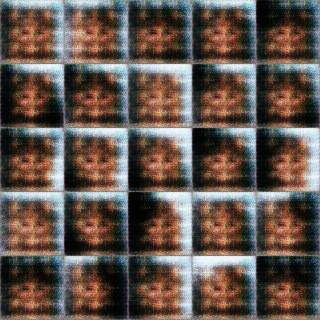

GIF: /content/dcgan_progress.gif


In [26]:
import imageio
from IPython.display import Image as IPyImage, display

if len(sample_paths) == 0:
    from glob import glob
    sample_paths = sorted(glob(os.path.join(SAMPLES_DIR, "epoch_*.png")))

frames = [imageio.imread(p) for p in sample_paths]
imageio.mimsave(GIF_PATH, frames, fps=4)

display(IPyImage(filename=GIF_PATH))
print("GIF:", GIF_PATH)

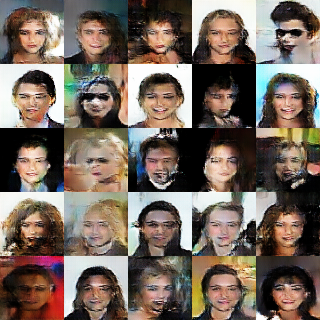

Saved: /content/dcgan_final_grid.png


In [27]:
final_grid_path = "/content/dcgan_final_grid.png"
z = tf.random.normal([25, NOISE_DIM])
gen = generator(z, training=False)
gen = denorm(gen)
save_grid(gen, final_grid_path, grid=5)

from IPython.display import Image as IPyImage, display
display(IPyImage(filename=final_grid_path))
print("Saved:", final_grid_path)